# <center> Decision Tree and Random Forest

## Demo:01 Random Forest model in 4 Steps
- Get all feature lists and  use 'Year' as the target column for classification
- Standardize the features then fit the model
- Get details of features
- Plot the result using scatter plot 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Load the data from the CSV file
data = pd.read_csv('output.csv')

# Extract the features and target variable for Random Forest
features = data[['Month', 'Year', 'Patient_Spend', 'Patient_Visits']]
target = data['Year']  # Using 'Year' as the target column for classification

In [4]:
# Standardize the features
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)

In [5]:
# Create and fit the Random Forest model
rf = RandomForestClassifier(random_state=0)
rf.fit(features_standardized, target)

RandomForestClassifier(random_state=0)

In [6]:
# Get feature importances
feature_importances = rf.feature_importances_

print(feature_importances)

[0.00301413 0.97210724 0.01250842 0.01237021]


In [7]:
# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': ['Month', 'Year', 'Patient_Spend', 'Patient_Visits'],
    'Importance': feature_importances
})

In [8]:
# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

# Display the feature importances DataFrame
print(feature_importance_df)

          Feature  Importance
0           Month    0.003014
3  Patient_Visits    0.012370
2   Patient_Spend    0.012508
1            Year    0.972107


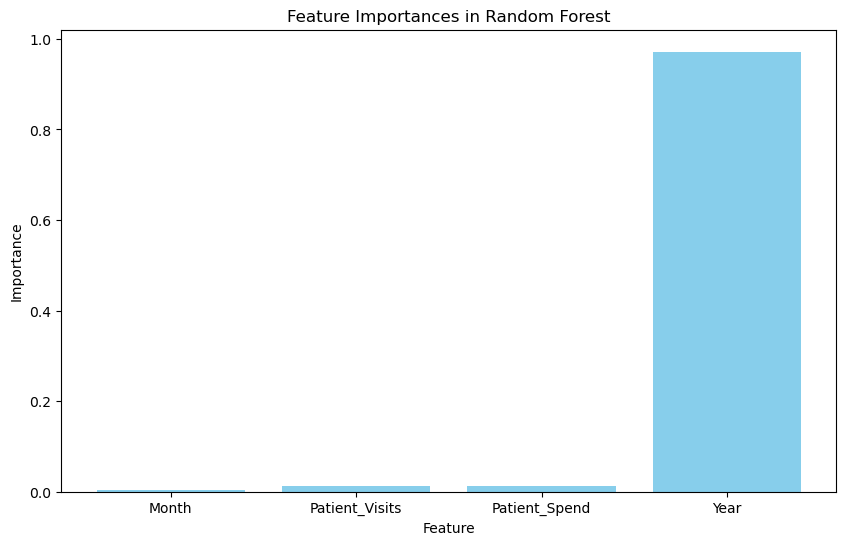

In [9]:
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances in Random Forest')
plt.show()

## Demo:02 Decision Tree Classifier model in 4 Steps

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load the data from the CSV file
data = pd.read_csv('output.csv')

In [12]:
# Create a binary target variable, e.g., classify high spending patients (1) vs. low spending (0)
data['High_Spend'] = (data['Patient_Spend'] > 2500).astype(int)

In [13]:
# Separate features and target variable
X = data[['Month', 'Year', 'Patient_Spend', 'Patient_Visits']]
y = data['High_Spend']

# Step: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# Step: Train the Decision Tree Model
# Initialize the DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)  # Limiting depth for simplicity
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [15]:
# Step: Make Predictions and Evaluate
y_pred = dt_model.predict(X_test)

In [16]:
# Calculate accuracy and print evaluation metrics
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       754
           1       1.00      1.00      1.00      1246

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



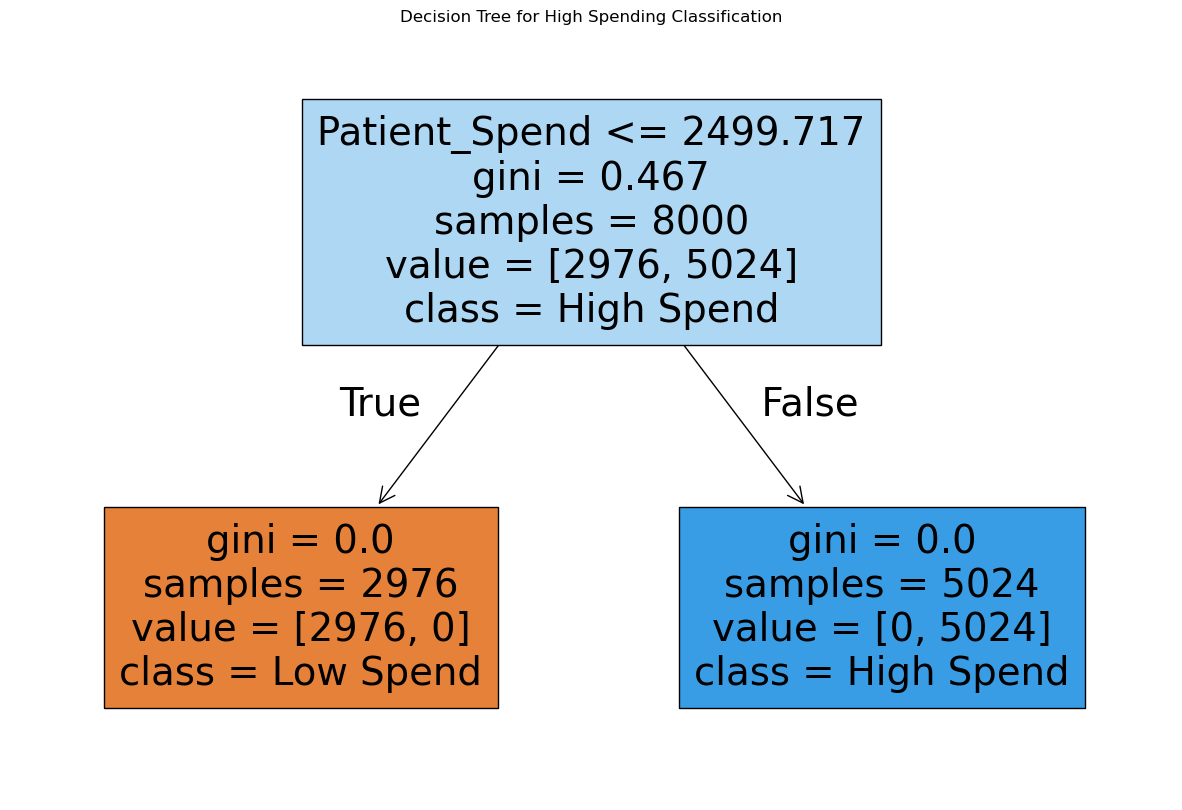

In [17]:
# Step: Visualize the Decision Tree
plt.figure(figsize=(15, 10))
plot_tree(dt_model, feature_names=['Month', 'Year', 'Patient_Spend', 'Patient_Visits'],
          class_names=['Low Spend', 'High Spend'], filled=True)
plt.title("Decision Tree for High Spending Classification")
plt.show()
